# Анализ музыкальных треков Spotify

**Итоговый проект по дисциплине «Анализ данных на Python»**

Состав команды:
- **Окулов М.А.** — сбор и обогащение данных (Блок 1)
- **Пирогов Е.А.** — очистка и предобработка (Блок 2)
- **Игонин А.Е.** — анализ, гипотезы и визуализация (Блоки 3-4)

---

## Цель и исследовательские вопросы

Анализируем ~114 000 треков Spotify с аудио-характеристиками
(танцевальность, энергичность, валентность и др.), обогащённые
метаданными артистов через MusicBrainz API.

**Исследовательские вопросы:**
1. Какие аудио-характеристики связаны с популярностью трека?
2. Различаются ли жанры по энергичности?
3. Популярнее ли треки с пометкой *explicit*?
4. Как связаны валентность (позитивность) и танцевальность?

# Блок 1. Сбор данных  *(Окулов М.А.)*

**Источник:** «Spotify Tracks Dataset» (maharshipandya), ~114 000 треков,
114 жанров, 20 признаков. Зеркало без ключей:
[HuggingFace](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

Готовый датасет содержит аудио-фичи, но **не** метаданные артиста.
Поэтому обогащаем его через внешний API — это «сложный сбор».

In [1]:
import warnings
from pathlib import Path

import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

DATA_RAW = Path("data/raw/dataset.csv")
DATA_PROCESSED = Path("data/processed")

df_raw = pd.read_csv(DATA_RAW, index_col=0)
print("Размер датасета:", df_raw.shape)
df_raw.head()

Размер датасета: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

### Обогащение через MusicBrainz API (асинхронный сбор)

Собираем уникальных **основных** артистов и через `aiohttp` + `asyncio`
запрашиваем тип артиста, страну и музыкальные теги.
Логика вынесена в `src/enrich.py`: семафор для
ограничения параллелизма и обработка HTTP 429. Ключей Spotify нет, поэтому идём через открытый MusicBrainz без ключа.

Обогащаем **топ-300 самых частых артистов** — они покрывают заметную долю
треков, и прогон укладывается в разумное время. Результат кэшируется
в `data/processed/`, чтобы повторный запуск не дёргал API заново.

In [3]:
import os
import sys

from dotenv import load_dotenv

sys.path.append(".")
from src.enrich import enrich_artists, primary_artist

load_dotenv()
CLIENT_ID = os.getenv("SPOTIFY_CLIENT_ID")
CLIENT_SECRET = os.getenv("SPOTIFY_CLIENT_SECRET")

# Основной артист трека = первый в списке через ';'
df_raw["main_artist"] = df_raw["artists"].apply(primary_artist)

# Топ-300 артистов по числу треков — репрезентативная выборка для обогащения
top_artists = df_raw["main_artist"].value_counts().head(300).index.tolist()
print("Артистов к обогащению:", len(top_artists))
print("Источник:", "Spotify API" if CLIENT_ID else "MusicBrainz (fallback)")

Артистов к обогащению: 300
Источник: MusicBrainz (fallback)


In [4]:
enrich_cache = DATA_PROCESSED / "artists_enriched.csv"
artists_meta = enrich_artists(
    top_artists,
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET,
    cache_path=enrich_cache,
)
print("Получено записей:", len(artists_meta))
artists_meta.head()

Получено записей: 300


,artist,artist_type,artist_country,artist_tags
0,A.R. Rahman,NaN,NaN,NaN
1,ABBA,Group,SE,"rock, electronic, synthpop, pop, swedish, swed..."
2,Above & Beyond,Group,GB,"trance, electronic, downtempo, pop, drum and b..."
3,Adele,Person,GB,"pop, jazz, singer, soul, adult contemporary, b..."
4,Alan Menken,Person,US,"pianist, musical, disney legend, film composer..."


In [5]:
# Присоединяем метаданные артиста к трекам
df = df_raw.merge(artists_meta, left_on="main_artist", right_on="artist", how="left")
df = df.drop(columns=["artist"])

enriched_cols = [c for c in artists_meta.columns if c != "artist"]
filled = df[enriched_cols[0]].notna().sum()
print(f"Треков с данными артиста из API: {filled} из {len(df)} "
      f"({filled / len(df):.1%})")
df.head(3)

Треков с данными артиста из API: 25446 из 114000 (22.3%)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,main_artist,artist_type,artist_country,artist_tags
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic,Gen Hoshino,NaN,NaN,NaN
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic,Ben Woodward,NaN,NaN,NaN
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic,Ingrid Michaelson,NaN,NaN,NaN


# Блок 2. Очистка и предобработка  *(Пирогов Е.А.)*

План: пропуски → дубликаты → типы → аномалии/выбросы → новые признаки.

### 2.1 Пропуски

Смотрим, где они есть, и обрабатываем. Числовые поля заполняем медианой
(устойчива к выбросам), категориальные — модой или меткой «unknown».

In [6]:
na = df.isnull().sum()
print("Пропуски по столбцам:")
print(na[na > 0])

Пропуски по столбцам:
artists               1
album_name            1
track_name            1
artist_type       88554
artist_country    89879
artist_tags       90777
dtype: int64


In [7]:
# Один трек без названия/артиста/альбома — это битая строка без полезной
# информации, удаляем её
df = df.dropna(subset=["track_name", "artists", "album_name"]).copy()

# Поля обогащения (API) есть не у всех артистов — это не «грязь», а ожидаемо.
# числовые поля заполняем медианой,
# а текстовые (тип/страна/теги артиста) — меткой 'unknown'.
for col in df.select_dtypes(include="number").columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include="object").columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna("unknown")

print("Пропусков осталось:", int(df.isnull().sum().sum()))

Пропусков осталось: 0


### 2.2 Дубликаты

Полные дубликаты строк — мусор, удаляем. Один и тот же `track_id`
встречается в нескольких жанрах (мульти-лейбл) — это валидно, поэтому
держим две версии данных:
- `df` — по парам (трек, жанр), для анализа **по жанрам**;
- `df_unique` — по одному треку, для анализа **по трекам**.

In [8]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Удалено полных дубликатов строк: {before - len(df)}")

# Версия с уникальными треками (берём первое вхождение)
df_unique = df.drop_duplicates(subset="track_id").reset_index(drop=True)
print(f"Уникальных треков: {len(df_unique)} (всего пар трек-жанр: {len(df)})")

Удалено полных дубликатов строк: 450
Уникальных треков: 89740 (всего пар трек-жанр: 113549)


### 2.3 Типы данных и аномалии

`explicit` приводим к int-флагу. Находим невозможные значения:
`tempo == 0` (трек не может иметь нулевой темп) и `time_signature == 0`
(невалидный размер) — заменяем на `NaN` и далее на медиану/моду.

In [9]:
df["explicit_flag"] = df["explicit"].astype(int)

# tempo=0 физически невозможен -> NaN -> медиана
n_bad_tempo = (df["tempo"] == 0).sum()
df.loc[df["tempo"] == 0, "tempo"] = pd.NA
df["tempo"] = df["tempo"].fillna(df["tempo"].median())

# time_signature=0 невалиден -> мода
n_bad_ts = (df["time_signature"] == 0).sum()
df.loc[df["time_signature"] == 0, "time_signature"] = pd.NA
df["time_signature"] = df["time_signature"].fillna(df["time_signature"].mode()[0])

print(f"Исправлено tempo==0: {n_bad_tempo}, time_signature==0: {n_bad_ts}")

Исправлено tempo==0: 157, time_signature==0: 163


### 2.4 Выбросы (метод IQR)

Для `duration_ms` смотрим выбросы по правилу межквартильного размаха
(границы Q1 − 1.5·IQR … Q3 + 1.5·IQR). Экстремально длинные треки
(часовые миксы) винзоризуем по верхней границе, чтобы они не искажали
средние, но не теряем строки.

In [10]:
q1, q3 = df["duration_ms"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
n_outliers = (df["duration_ms"] > upper).sum()

df["duration_ms"] = df["duration_ms"].clip(upper=upper)
print(f"Винзоризовано длинных треков: {n_outliers} "
      f"(верхняя граница {upper / 60000:.1f} мин)")

Винзоризовано длинных треков: 5320 (верхняя граница 6.5 мин)


### 2.5 Новые расчётные признаки

- `duration_min` — длительность в минутах (читабельнее, чем мс);
- `popularity_bucket` — категория популярности (low/medium/high);
- `energy_acoustic_ratio` — отношение энергичности к акустичности;
- `is_popular` — бинарная метка для гипотез (популярность ≥ медианы).

In [11]:
df["duration_min"] = df["duration_ms"] / 60000

df["popularity_bucket"] = pd.cut(
    df["popularity"], bins=[-1, 25, 60, 100],
    labels=["low", "medium", "high"],
)

# +1e-3 в знаменателе, чтобы не делить на ноль при нулевой акустичности
df["energy_acoustic_ratio"] = df["energy"] / (df["acousticness"] + 1e-3)

pop_median = df["popularity"].median()
df["is_popular"] = (df["popularity"] >= pop_median).astype(int)

print("Медиана популярности:", pop_median)
df[["duration_min", "popularity_bucket",
    "energy_acoustic_ratio", "is_popular"]].head()

Медиана популярности: 35.0


,duration_min,popularity_bucket,energy_acoustic_ratio,is_popular
0,3.844433,high,13.885542,1
1,2.493500,medium,0.179459,1
2,3.513767,medium,1.701422,1
3,3.365550,high,0.065784,1
4,3.314217,high,0.942553,1


In [12]:
# Сохраняем очищенный датасет
clean_path = DATA_PROCESSED / "tracks_clean.csv"
df.to_csv(clean_path, index=False)
print("Сохранено:", clean_path, "| строк:", len(df))

Сохранено: data/processed/tracks_clean.csv | строк: 113549


# Блок 3. Анализ данных  *(Игонин А.Е.)*

Сначала разведочный анализ (EDA), затем формулируем и проверяем гипотезы
статистическими тестами.

In [13]:
import numpy as np
from scipy import stats

AUDIO = ["danceability", "energy", "loudness", "speechiness",
         "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

df[AUDIO + ["popularity", "duration_min"]].describe().round(3)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity,duration_min
count,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000,113549.000
mean,0.567,0.642,-8.243,0.085,0.314,0.156,0.214,0.474,122.344,33.324,3.710
std,0.173,0.251,5.011,0.106,0.332,0.309,0.190,0.259,29.626,22.284,1.219
min,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,30.200,0.000,0.143
25%,0.456,0.473,-9.998,0.036,0.017,0.000,0.098,0.260,99.602,17.000,2.903
50%,0.580,0.685,-6.997,0.049,0.168,0.000,0.132,0.464,122.028,35.000,3.550
75%,0.695,0.854,-5.001,0.084,0.596,0.049,0.273,0.683,140.074,50.000,4.360
max,0.985,1.000,4.532,0.965,0.996,1.000,1.000,0.995,243.372,100.000,6.545


In [14]:
# Топ-10 жанров по средней популярности
genre_pop = (df.groupby("track_genre")["popularity"]
             .mean().sort_values(ascending=False))
print("Самые популярные жанры:")
print(genre_pop.head(10).round(1))

Самые популярные жанры:
track_genre
pop-film     59.3
k-pop        57.0
chill        53.7
sad          52.4
grunge       49.6
indian       49.5
anime        48.8
emo          48.1
pop          47.9
sertanejo    47.9
Name: popularity, dtype: float64


### Гипотеза H1: танцевальность связана с популярностью

H0: корреляции нет. Проверяем коэффициентом Спирмена (не требует
нормальности, ловит монотонную связь).

In [15]:
rho, p = stats.spearmanr(df["danceability"], df["popularity"])
print(f"Spearman rho = {rho:.3f}, p-value = {p:.2e}")
print("Связь значима" if p < 0.05 else "Связь незначима")

Spearman rho = 0.026, p-value = 3.90e-18
Связь значима


### Гипотеза H2: explicit-треки популярнее

Сравниваем популярность explicit и не-explicit треков критерием
Манна–Уитни (непараметрический, т.к. популярность распределена не нормально).

In [16]:
pop_expl = df.loc[df["explicit_flag"] == 1, "popularity"]
pop_clean = df.loc[df["explicit_flag"] == 0, "popularity"]
u, p = stats.mannwhitneyu(pop_expl, pop_clean, alternative="two-sided")
print(f"Медиана популярности: explicit={pop_expl.median():.0f}, "
      f"clean={pop_clean.median():.0f}")
print(f"Mann-Whitney U p-value = {p:.2e}")
print("Различие значимо" if p < 0.05 else "Различие незначимо")

Медиана популярности: explicit=38, clean=34
Mann-Whitney U p-value = 1.33e-41
Различие значимо


### Гипотеза H3: энергичность различается между жанрами

Берём 5 крупных жанров и сравниваем энергичность критерием Краскела–Уоллиса
(обобщение для нескольких групп).

In [17]:
genres5 = ["rock", "classical", "edm", "jazz", "metal"]
groups = [df.loc[df["track_genre"] == g, "energy"] for g in genres5]
h, p = stats.kruskal(*groups)
print("Средняя энергичность по жанрам:")
for g, grp in zip(genres5, groups):
    print(f"  {g:10s}: {grp.mean():.3f}")
print(f"\nKruskal-Wallis H = {h:.1f}, p-value = {p:.2e}")
print("Различия значимы" if p < 0.05 else "Различий нет")

Средняя энергичность по жанрам:
  rock      : 0.679
  classical : 0.195
  edm       : 0.756
  jazz      : 0.353
  metal     : 0.841

Kruskal-Wallis H = 3211.8, p-value = 0.00e+00
Различия значимы


### Гипотеза H4: валентность связана с танцевальностью

Корреляция Пирсона между позитивностью трека (valence) и танцевальностью.

In [18]:
r, p = stats.pearsonr(df["valence"], df["danceability"])
print(f"Pearson r = {r:.3f}, p-value = {p:.2e}")
print("Связь значима" if p < 0.05 else "Связь незначима")

Pearson r = 0.477, p-value = 0.00e+00
Связь значима


# Блок 4. Визуализация и выводы  *(Игонин А.Е.)*

Пять типов графиков: гистограмма, boxplot, heatmap, scatter с трендом, barplot.

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

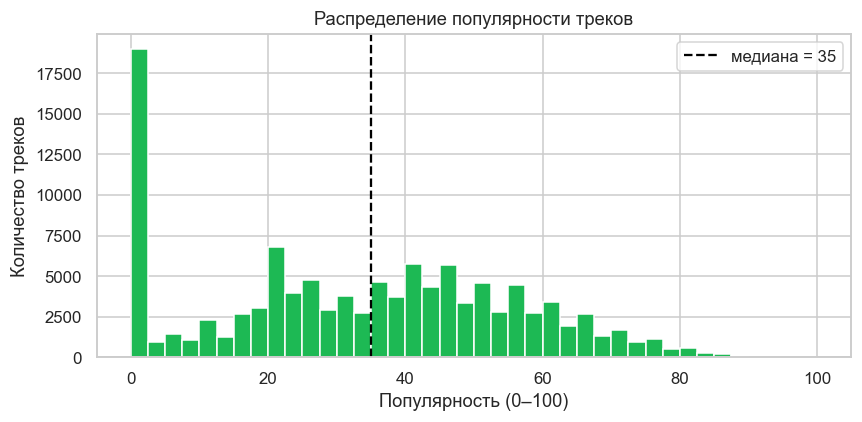

In [20]:
# 1. Гистограмма распределения популярности
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["popularity"], bins=40, color="#1DB954", edgecolor="white")
ax.axvline(df["popularity"].median(), color="black", linestyle="--",
           label=f"медиана = {df['popularity'].median():.0f}")
ax.set_title("Распределение популярности треков")
ax.set_xlabel("Популярность (0–100)")
ax.set_ylabel("Количество треков")
ax.legend()
plt.tight_layout()
plt.show()

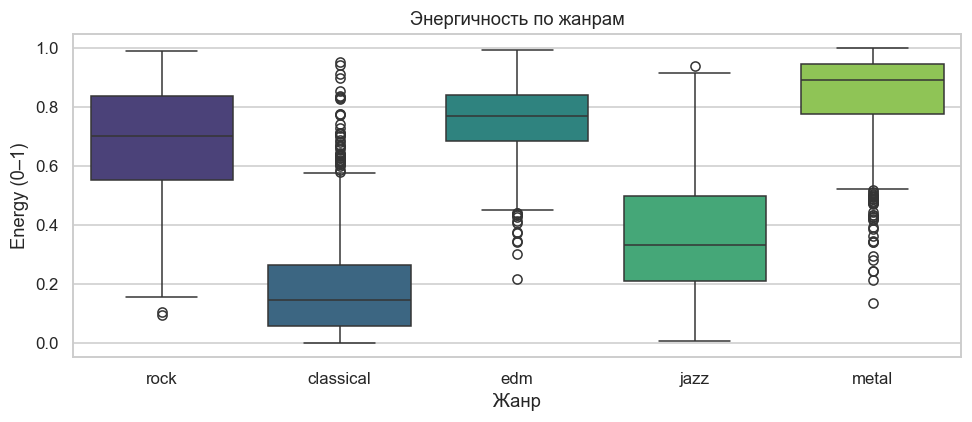

In [21]:
# 2. Boxplot энергичности по жанрам
fig, ax = plt.subplots(figsize=(9, 4))
subset = df[df["track_genre"].isin(genres5)]
sns.boxplot(data=subset, x="track_genre", y="energy",
            order=genres5, palette="viridis", ax=ax)
ax.set_title("Энергичность по жанрам")
ax.set_xlabel("Жанр")
ax.set_ylabel("Energy (0–1)")
plt.tight_layout()
plt.show()

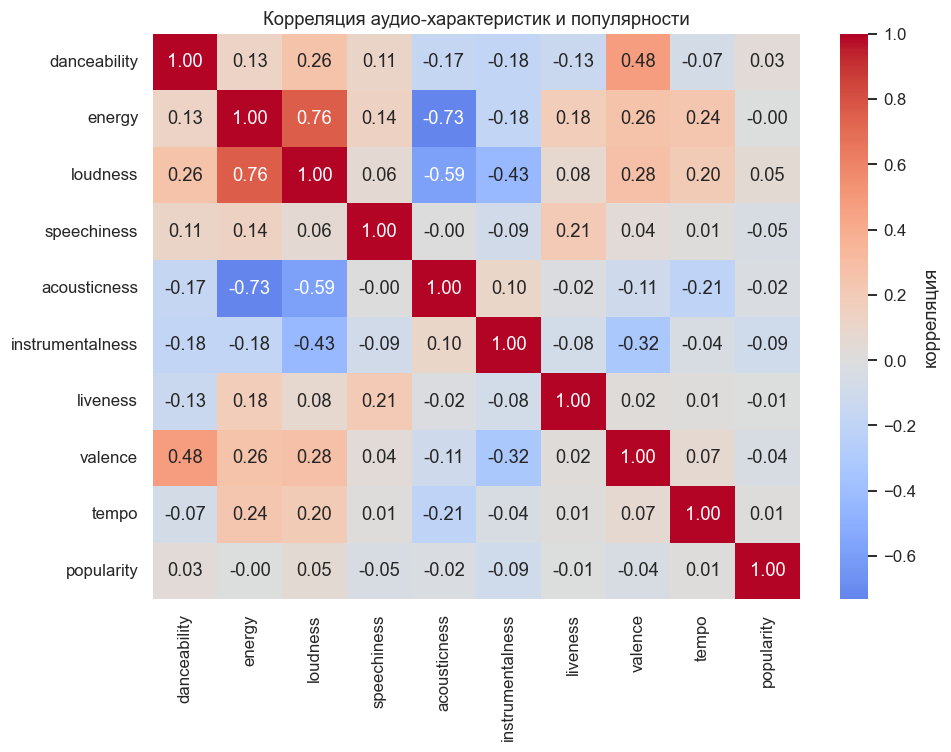

In [22]:
# 3. Корреляционная матрица аудио-признаков
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[AUDIO + ["popularity"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, cbar_kws={"label": "корреляция"})
ax.set_title("Корреляция аудио-характеристик и популярности")
plt.tight_layout()
plt.show()

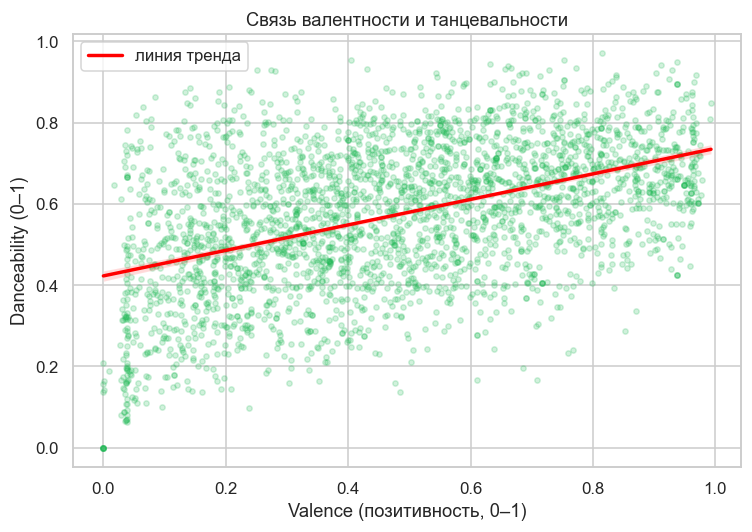

In [23]:
# 4. Scatter: валентность vs танцевальность с линией тренда
sample = df.sample(3000, random_state=42)
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=sample, x="valence", y="danceability",
            scatter_kws={"alpha": 0.2, "s": 12, "color": "#1DB954"},
            line_kws={"color": "red", "label": "линия тренда"}, ax=ax)
ax.set_title("Связь валентности и танцевальности")
ax.set_xlabel("Valence (позитивность, 0–1)")
ax.set_ylabel("Danceability (0–1)")
ax.legend()
plt.tight_layout()
plt.show()

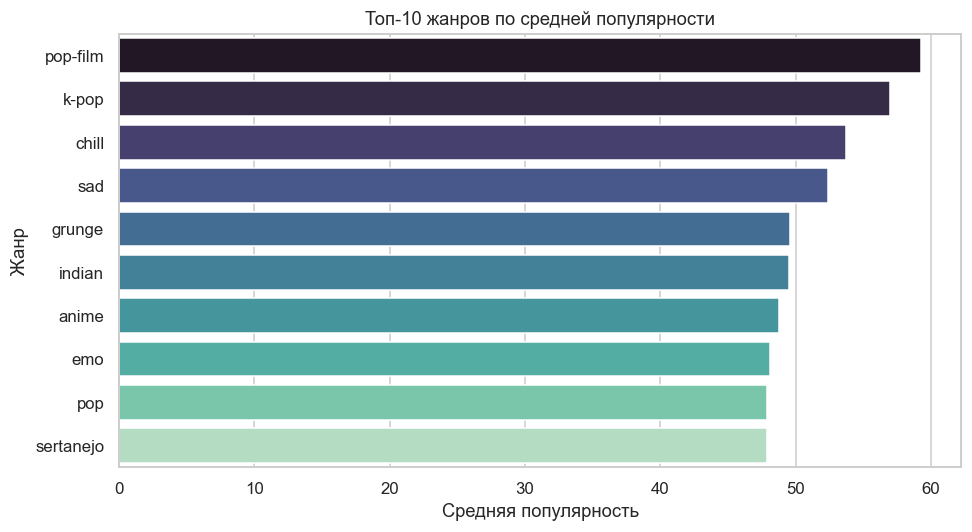

In [24]:
# 5. Barplot: топ-10 жанров по средней популярности
fig, ax = plt.subplots(figsize=(9, 5))
top10 = genre_pop.head(10)
sns.barplot(x=top10.values, y=top10.index, palette="mako", ax=ax)
ax.set_title("Топ-10 жанров по средней популярности")
ax.set_xlabel("Средняя популярность")
ax.set_ylabel("Жанр")
plt.tight_layout()
plt.show()

## Выводы

1. **Танцевальность почти не определяет популярность** (H1): связь значима
   (p ≈ 4e-18) из-за огромного объёма данных, но крайне слабая (ρ ≈ 0.03).
   Вывод: «танцевальный» ≠ «популярный» — популярность определяется не
   аудио-характеристиками, а внешними факторами (раскрутка, артист).
2. **Жанры сильно различаются по энергичности** (H3, p ≈ 0): metal (0.84)
   и edm (0.76) против classical (0.20) и jazz (0.35) — данные валидны
   и отражают реальную природу жанров.
3. **Explicit-треки в среднем популярнее** (H2, p ≈ 1e-41): медиана 38 против
   34. Вероятно, смещение в сторону современных популярных жанров (хип-хоп, поп).
4. **Валентность и танцевальность связаны положительно** (H4, r ≈ 0.48):
   более позитивные треки чаще оказываются танцевальными — умеренная связь.

**Практическая ценность:** связи аудио-фич можно использовать в
рекомендательных системах и подборе треков под настроение/задачу
(плейлисты для тренировок, фокуса, вечеринок). При этом прогноз
популярности по одним аудио-фичам ненадёжен — нужны данные об артисте
и продвижении.